# Lecture 10 — Evaluation and Anomaly Detection

**01211271 Industrial AI and IoT** · Electromechanical Manufacturing Engineering

---

Lecture 9 ended with a linear SVM scoring 0.880 and a sense that the hard part was
over. This lecture takes both of those away.

The first half is about **evaluation**: what accuracy hides, how to see it, and how to
choose an operating point when a missed bearing spall and a needless inspection cost
wildly different amounts. The second half is about the situation every real plant is
actually in — **plenty of healthy data and almost no labelled faults** — and what you
can still build from that.

The dataset changes today, and the change is the point. Lecture 8 and 9 used sixteen
runs of each fault, perfectly balanced. No factory has that. Today we use a fleet:
150 acquisitions, of which six are bearing spalls.

## Learning objectives

By the end of this notebook you should be able to:

1. Explain why accuracy is a poor score on imbalanced data, and compute what a useless
   model would score.
2. Read a confusion matrix and derive precision, recall and F1 from it.
3. Turn a stated cost ratio into a decision threshold, and show that it is not the
   default one.
4. Use class weights knowingly — and say what they trade away.
5. Cross-validate with groups and a rare class, and report the spread honestly.
6. Build an anomaly detector from healthy data alone and set its threshold from a
   quantile.
7. Recognise concept drift and explain why a threshold has a shelf life.

## Prerequisites

Lecture 8 (windowing, the twelve features, splitting by run) and Lecture 9 (the
train/validation/test protocol, and the linear SVM we will reuse unchanged).

## The running example

The same rotor rig, but a fleet of them, monitored for a year. Fault severity now
spans incipient to severe, because the faults worth catching early are the faint ones.

In [1]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn

print("python     ", sys.version.split()[0])
for m in (np, pd, matplotlib, sklearn):
    print(f"{m.__name__:<11}", m.__version__)

plt.rcParams.update({"figure.figsize": (10.5, 3.6), "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.35,
                     "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, AQUA, VIOLET, RED = ("#2a78d6", "#eb6834", "#1baf7a",
                                   "#4a3aa7", "#e34948")
LAB = ["normal", "imbalance", "bearing"]

python      3.11.15
numpy       2.4.4
pandas      3.0.2
matplotlib  3.10.9
sklearn     1.8.0


## The data

`rig.py` from Lectures 8 and 9, unchanged, with two new campaigns at the bottom:

* `make_fleet()` — 150 acquisitions with industrial prevalence and a wide range of
  fault severity.
* `make_drift_campaign()` — one healthy machine measured monthly for four years, with
  a slow baseline drift and a real spall at the end. Used in section 9.

In [2]:
"""
rig.py — the rotor-rig simulator shared by Lectures 8-14
01211271 Industrial AI and IoT

Synthetic but physics-motivated vibration data for a small motor-driven rotor rig.

Rig model
---------
A 3-phase induction motor drives a rotor disc supported by two rolling-element
bearings.  A MEMS accelerometer is mounted radially on the drive-end bearing
housing and sampled at fs = 2000 Hz.

Three machine states are simulated:

  normal    : residual unbalance only -> modest 1x shaft-rate component
  imbalance : added trial mass on the disc -> large 1x component
  bearing   : outer-race spall -> periodic impulses at BPFO that ring the
              bearing housing resonance

Outer-race defect frequency, for a bearing with n = 9 balls, ball/pitch
diameter ratio d/D = 0.2 and contact angle 0:

    BPFO = (n/2) * (1 - (d/D) cos(phi)) * f_r = 4.5 * 0.8 * f_r = 3.6 * f_r

so at a nominal 30 Hz shaft rate (1800 rpm) the impulses arrive at 108 Hz.

Every run carries its own nuisance variation -- shaft speed, sensor gain,
broadband noise floor, DC bias and a structural tone.  This is what makes a
random train/test split across overlapping windows dishonest: the model can
memorise the run, not the fault.

Lecture 8 built the classification dataset from make_dataset().  Lecture 9 adds
make_speed_sweep(), a separate acquisition campaign used for the soft-sensor
thread: the rig is run across its speed range in the healthy state so that a
regression model can learn to read shaft speed off the vibration alone.
"""

import numpy as np

# ----------------------------------------------------------------- constants
FS = 2000.0                 # sampling rate, Hz
RUN_SECONDS = 4.0           # length of one acquisition run
RUNS_PER_CLASS = 16
CLASSES = ("normal", "imbalance", "bearing")

WIN = 256                   # default window length, samples (128 ms)
HOP = 128                   # 50 % overlap

F_RESONANCE = 600.0         # bearing housing resonance, Hz
TAU_RING = 0.0012           # impulse ring-down time constant, s
BPFO_RATIO = 3.6            # outer-race defect order

# Fixed analysis bands, Hz.  Shaft speed wanders over 28-32 Hz, so the bands
# are wide enough to hold the order they are named for without a tachometer.
BANDS = {
    "e_1x":   (20.0, 42.0),     # shaft rate
    "e_2x":   (48.0, 78.0),     # twice shaft rate
    "e_bpfo": (90.0, 132.0),    # outer-race defect order
    "e_hi":   (400.0, 900.0),   # housing resonance region
}

FEATURE_NAMES = [
    "mean", "rms", "std", "ptp", "crest", "kurt", "zcr",
    "dom_freq", "e_1x", "e_2x", "e_bpfo", "e_hi",
]


# ------------------------------------------------------------ signal synthesis
def _run_params(rng, state):
    """Nuisance parameters that vary from one acquisition run to the next."""
    return dict(
        f_r=rng.uniform(28.0, 32.0),          # shaft rate, Hz
        gain=rng.uniform(0.85, 1.25),         # sensor / mounting gain
        noise=rng.uniform(0.04, 0.20),        # broadband floor, g rms
        bias=rng.uniform(-0.06, 0.06),        # accelerometer DC offset, g
        f_struct=rng.uniform(150.0, 700.0),   # frame resonance -- a confounder
        a_struct=rng.uniform(0.03, 0.15),
        a_1x=(rng.uniform(0.20, 0.38) if state != "imbalance"
              else rng.uniform(0.58, 1.10)),
        a_imp=(rng.uniform(0.45, 1.40) if state == "bearing" else 0.0),
    )


def _synth(rng, p, seconds=RUN_SECONDS, fs=FS):
    """Turn a parameter dict into a waveform.  Shared by every campaign."""
    n = int(seconds * fs)
    t = np.arange(n) / fs

    ph = rng.uniform(0, 2 * np.pi, 4)
    x = (p["a_1x"] * np.sin(2 * np.pi * p["f_r"] * t + ph[0])
         + 0.32 * p["a_1x"] * np.sin(2 * np.pi * 2 * p["f_r"] * t + ph[1])
         + 0.12 * p["a_1x"] * np.sin(2 * np.pi * 3 * p["f_r"] * t + ph[2])
         + p["a_struct"] * np.sin(2 * np.pi * p["f_struct"] * t + ph[3]))

    if p["a_imp"] > 0:
        f_bpfo = BPFO_RATIO * p["f_r"]
        period = fs / f_bpfo
        k = 0
        while True:
            # 1 % random slip, as real rolling elements do
            idx = int(k * period * (1.0 + rng.normal(0, 0.01)))
            if idx >= n:
                break
            tail = np.arange(n - idx) / fs
            ring = (p["a_imp"] * rng.uniform(0.75, 1.25)
                    * np.exp(-tail / TAU_RING)
                    * np.sin(2 * np.pi * F_RESONANCE * tail))
            x[idx:] += ring
            k += 1

    x = p["gain"] * (x + rng.normal(0, p["noise"], n)) + p["bias"]
    return x.astype(np.float64)


def make_run(rng, state, seconds=RUN_SECONDS, fs=FS):
    """Synthesise one acquisition run.  Returns (signal, params)."""
    p = _run_params(rng, state)
    return _synth(rng, p, seconds, fs), p


def make_dataset(seed=7, runs_per_class=RUNS_PER_CLASS):
    """All runs.  Returns list of dicts with signal, label and run id."""
    rng = np.random.default_rng(seed)
    runs, rid = [], 0
    for state in CLASSES:
        for _ in range(runs_per_class):
            x, p = make_run(rng, state)
            runs.append({"x": x, "label": state, "run": rid, "params": p})
            rid += 1
    return runs


# ------------------------------------------------------------------- features
def frame(x, win=WIN, hop=HOP):
    """Slice a 1-D signal into overlapping windows -> (n_windows, win)."""
    n = 1 + (len(x) - win) // hop
    idx = np.arange(win)[None, :] + hop * np.arange(n)[:, None]
    return x[idx]


def time_features(w):
    """Seven time-domain features for each row of w."""
    mean = w.mean(axis=1)
    ac = w - mean[:, None]                      # remove DC before anything else
    rms = np.sqrt((ac ** 2).mean(axis=1))
    std = ac.std(axis=1)
    ptp = np.ptp(w, axis=1)
    peak = np.abs(ac).max(axis=1)
    crest = peak / np.maximum(rms, 1e-12)
    m4 = (ac ** 4).mean(axis=1)
    kurt = m4 / np.maximum(rms, 1e-12) ** 4     # non-excess kurtosis; 3.0 = Gaussian
    zc = np.diff(np.signbit(ac).astype(np.int8), axis=1)
    zcr = np.abs(zc).sum(axis=1) / (w.shape[1] - 1)
    return np.column_stack([mean, rms, std, ptp, crest, kurt, zcr])


def freq_features(w, fs=FS, normalise=True):
    """Dominant frequency plus four band energies.

    normalise=True gives each band as a fraction of the window's total power,
    which makes the feature independent of sensor gain.  normalise=False gives
    the absolute band power, whose units and magnitude differ wildly from the
    time-domain features -- useful for showing when feature scaling matters.
    """
    n = w.shape[1]
    win = np.hanning(n)
    ac = w - w.mean(axis=1, keepdims=True)
    spec = np.abs(np.fft.rfft(ac * win, axis=1)) ** 2
    f = np.fft.rfftfreq(n, 1.0 / fs)
    spec[:, 0] = 0.0                            # DC carries no information here
    total = np.maximum(spec.sum(axis=1), 1e-20)

    dom = f[spec.argmax(axis=1)]
    cols = [dom]
    for lo, hi in BANDS.values():
        m = (f >= lo) & (f < hi)
        band = spec[:, m].sum(axis=1)
        cols.append(band / total if normalise else band)
    return np.column_stack(cols)


def features_of(w, fs=FS, normalise=True):
    """Full 12-feature vector for each row of w."""
    return np.column_stack([time_features(w), freq_features(w, fs, normalise)])


def build_table(runs, win=WIN, hop=HOP, fs=FS, normalise=True):
    """Turn the raw runs into the (X, y, groups) learning problem."""
    X, y, g = [], [], []
    for r in runs:
        w = frame(r["x"], win, hop)
        X.append(features_of(w, fs, normalise))
        y += [r["label"]] * w.shape[0]
        g += [r["run"]] * w.shape[0]
    return np.vstack(X), np.array(y), np.array(g)


def raw_table(runs, win=WIN, hop=HOP):
    """The naive alternative: the raw samples of each window as the features."""
    X, y, g = [], [], []
    for r in runs:
        w = frame(r["x"], win, hop)
        X.append(w)
        y += [r["label"]] * w.shape[0]
        g += [r["run"]] * w.shape[0]
    return np.vstack(X), np.array(y), np.array(g)


# ------------------------------------------------- Lecture 9: the speed sweep
SWEEP_RUNS = 40
SWEEP_FR = (22.0, 40.0)     # stays inside the e_1x band (20-42 Hz)


def make_speed_sweep(seed=11, n_runs=SWEEP_RUNS, seconds=RUN_SECONDS):
    """A healthy-machine speed sweep, for the virtual tachometer.

    The rig has no tachometer.  To build one in software you run the machine
    across its speed range in a known-good state and record the true shaft
    speed from the drive's own setpoint.  Each run still carries its own gain,
    noise floor, bias and frame resonance -- the soft sensor has to work in
    spite of those, not because of them.

    Returns a list of dicts with the signal, the true shaft speed and a run id.
    """
    rng = np.random.default_rng(seed)
    runs = []
    for rid in range(n_runs):
        p = _run_params(rng, "normal")
        p["f_r"] = float(rng.uniform(*SWEEP_FR))
        x = _synth(rng, p, seconds, FS)
        runs.append({"x": x, "f_r": p["f_r"],
                     "run": rid, "params": p})
    return runs


def build_speed_table(runs, win=WIN, hop=HOP, fs=FS):
    """(X, y, groups) for the soft sensor.  y is the true shaft speed in Hz."""
    X, y, g = [], [], []
    for r in runs:
        w = frame(r["x"], win, hop)
        X.append(features_of(w, fs))
        y += [r["f_r"]] * w.shape[0]
        g += [r["run"]] * w.shape[0]
    return np.vstack(X), np.array(y), np.array(g)


# =========================================== Lecture 10: the fleet campaign
# A year of monitoring across a fleet of nominally identical rigs.  Faults are
# RARE, and the ones you catch early are mild -- which is the whole point of
# catching them early, and the reason recall is hard.
FLEET_N = {"normal": 132, "imbalance": 12, "bearing": 6}


def _fleet_params(rng, state):
    """Run parameters for the fleet.  Fault severity spans incipient to severe."""
    p = _run_params(rng, state)
    if state == "imbalance":
        # a light trial mass barely shifts 1x; a thrown blade is unmistakable
        p["a_1x"] = float(rng.uniform(0.42, 1.10))
    if state == "bearing":
        # an early spall rings faintly; a spalled race is loud
        p["a_imp"] = float(rng.uniform(0.22, 1.40))
    return p


def make_fleet(seed=23, counts=None, seconds=RUN_SECONDS, fs=FS):
    """One acquisition per machine per month, across a fleet.

    Returns runs in a shuffled order with a 'label' and a 'severity' field.
    Prevalence is industrial, not academic: most machines are fine, a few have
    imbalance, and bearing spalls are rarer still.
    """
    counts = counts or FLEET_N
    rng = np.random.default_rng(seed)
    runs, rid = [], 0
    for state, n in counts.items():
        for _ in range(n):
            p = _fleet_params(rng, state)
            x = _synth(rng, p, seconds, fs)
            sev = (p["a_1x"] if state == "imbalance"
                   else p["a_imp"] if state == "bearing" else 0.0)
            runs.append({"x": x, "label": state, "run": rid,
                         "severity": float(sev), "params": p})
            rid += 1
    order = rng.permutation(len(runs))
    return [runs[i] for i in order]


# ============================================ Lecture 10: the drift campaign
# The same healthy machine, measured monthly for four years.  Nothing breaks --
# but the sensor mount relaxes, the ambient noise floor rises and the frame
# resonance walks.  A threshold set in the first year will not survive.
def make_drift_campaign(seed=31, n_months=48, fault_from=42, seconds=RUN_SECONDS,
                        fs=FS):
    """Healthy runs in time order with a slow baseline drift, then a real fault.

    Each run carries 'month'.  Runs from `fault_from` onward are a genuine
    bearing spall, so the last months contain something a detector SHOULD fire
    on -- everything before that is a healthy machine that merely looks
    different from how it looked in month 0.
    """
    rng = np.random.default_rng(seed)
    runs = []
    for m in range(n_months):
        t = m / (n_months - 1)                       # 0 -> 1 over the campaign
        faulty = m >= fault_from
        p = _run_params(rng, "bearing" if faulty else "normal")
        p["noise"] = float(0.06 + 0.050 * t + rng.normal(0, 0.005))
        p["a_struct"] = float(0.04 + 0.045 * t + rng.normal(0, 0.004))
        p["f_struct"] = float(180.0 + 110.0 * t + rng.normal(0, 8.0))
        p["gain"] = float(1.0 + 0.10 * t + rng.normal(0, 0.015))
        if faulty:
            p["a_imp"] = 1.10
        x = _synth(rng, p, seconds, fs)
        runs.append({"x": x, "label": "bearing" if faulty else "normal",
                     "run": m, "month": m, "params": p})
    return runs

In [3]:
fleet = make_fleet(seed=23)
X, y, groups = build_table(fleet)
run_labels = np.array([r["label"] for r in fleet])

print("runs in the fleet:")
print(pd.Series(run_labels).value_counts().reindex(LAB).to_string())
print(f"\n{X.shape[0]} windows × {X.shape[1]} features from {len(fleet)} runs")
print(f"faulty windows: {(y != 'normal').mean():.1%}")

runs in the fleet:
normal       132
imbalance     12
bearing        6

9150 windows × 12 features from 150 runs
faulty windows: 12.0%


## 1. The 0.880 that means nothing

Start with the model that does no work at all: always predict `normal`.

In [4]:
always_normal = np.full(len(y), "normal")
print(f"accuracy of 'always normal': {(always_normal == y).mean():.3f}")
print(f"bearing spalls it caught:    {(always_normal[y == 'bearing'] == 'bearing').sum()}")

accuracy of 'always normal': 0.880
bearing spalls it caught:    0


Look at that number and then look at Lecture 9, where the best of five tuned models
scored **0.880** and we called it a good result.

The two numbers are identical and one of them came from a model that has never
predicted a fault in its life. Accuracy is the fraction of windows you get right, and
when 88 % of windows are healthy, getting the healthy ones right is worth 0.880 on its
own.

> **Always compute the majority-class accuracy before you report anything.** If your
> model does not beat it by a margin you can defend, you have not built anything.

This is not a trick of the synthetic data. It is the normal condition of industrial
monitoring: the interesting event is rare, and the rarer it is, the more flattering
accuracy becomes.

## 2. What accuracy was hiding

Now the real model — Lecture 9's linear SVM, same hyperparameter, nothing changed
except the dataset it is asked to work on.

One thing does change: how we evaluate. With only six bearing runs in the whole fleet,
a single 60/20/20 split would leave one or two spalls in the test set, and a recall
estimated from one machine is not an estimate. Instead we use **out-of-fold
prediction**: five folds, each run held out exactly once, every window predicted by a
model that never saw its run. `StratifiedGroupKFold` keeps runs intact *and* balances
the class mix across folds.

In [5]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

C_SVM = 0.0032                       # chosen in Lecture 9, reused unchanged
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

def svm(**kw):
    return make_pipeline(StandardScaler(),
                         LinearSVC(C=C_SVM, max_iter=20000, **kw))

pred = cross_val_predict(svm(), X, y, groups=groups, cv=cv, n_jobs=-1)
print(f"accuracy: {(pred == y).mean():.4f}\n")
print(pd.DataFrame(confusion_matrix(y, pred, labels=LAB),
                   index=[f"actually {c}" for c in LAB],
                   columns=[f"called {c}" for c in LAB]).to_string())

accuracy: 0.9831

                    called normal  called imbalance  called bearing
actually normal              8052                 0               0
actually imbalance              0               732               0
actually bearing              155                 0             211


In [6]:
print(classification_report(y, pred, labels=LAB, digits=3, zero_division=0))

              precision    recall  f1-score   support

      normal      0.981     1.000     0.990      8052
   imbalance      1.000     1.000     1.000       732
     bearing      1.000     0.577     0.731       366

    accuracy                          0.983      9150
   macro avg      0.994     0.859     0.907      9150
weighted avg      0.983     0.983     0.981      9150



Accuracy went from 0.880 to 0.983. That looks like a triumph until you read the
bottom row of the matrix.

The four numbers that matter, and what each one answers:

| | definition | the question it answers |
|---|---|---|
| **recall** | TP / (TP + FN) | of the spalls that happened, how many did we catch? |
| **precision** | TP / (TP + FP) | of the alarms we raised, how many were real? |
| **F1** | harmonic mean of the two | one number when you refuse to choose |
| **support** | how many there were | how much to trust the other three |

Read them off the report:

* **Bearing recall is 0.577.** More than four spalls in ten go past unnoticed.
* **Bearing precision is 1.000.** When it does fire, it is never wrong.
* `normal` and `imbalance` are essentially perfect, and they are 96 % of the data —
  which is precisely why accuracy looked so good.

Imbalance being easy is not an accident of the simulator: a trial mass moves a lot of
metal and puts a large peak at a frequency we already have a feature for. An incipient
bearing spall is a small amount of energy, delivered sharply, at a frequency that
overlaps the structure. **The fault that is hardest to detect is usually the one you
most want to catch**, because catching it early is the entire value proposition.

> A confusion matrix costs one line of code and cannot be argued with. Report it.

## 3. A missed spall and a wasted inspection are not the same thing

Precision and recall trade against each other, and the classifier's default decision
boundary picks one point on that trade for reasons that have nothing to do with your
plant. To choose deliberately you need two things: a **continuous score** rather than a
hard label, and a **cost ratio**.

The score is `decision_function` — how far a window sits on the "bearing" side of the
boundary. The default prediction is simply `score > 0`.

The cost ratio is an engineering input, not a statistic. If a missed spall destroys a
gearbox and a false alarm costs an hour of a technician's time, the ratio is large. Ask
the maintenance manager; do not guess, and write down what you were told.

In [7]:
is_bear = (y == "bearing").astype(int)
score = cross_val_predict(svm(), X, is_bear, groups=groups, cv=cv,
                          method="decision_function", n_jobs=-1)

def stats_at(t):
    yhat = score > t
    tp = int((yhat & (is_bear == 1)).sum())
    fp = int((yhat & (is_bear == 0)).sum())
    fn = int((~yhat & (is_bear == 1)).sum())
    return dict(recall=tp / max(1, tp + fn),
                precision=tp / max(1, tp + fp),
                false_alarm_rate=fp / int((is_bear == 0).sum()))

def expected_cost(t, ratio):
    '''Cost per 1000 windows, with a false alarm costing 1 unit.'''
    yhat = score > t
    fn = int((~yhat & (is_bear == 1)).sum())
    fp = int((yhat & (is_bear == 0)).sum())
    return (ratio * fn + fp) / len(y) * 1000

ts = np.linspace(score.min(), score.max(), 400)
rows = []
for ratio in (10, 100):
    costs = np.array([expected_cost(t, ratio) for t in ts])
    t_best = ts[int(np.argmin(costs))]
    s = stats_at(t_best)
    rows.append({"cost ratio": f"{ratio}:1", "best threshold": t_best,
                 "recall": s["recall"], "false alarms": s["false_alarm_rate"],
                 "cost at best": costs.min(),
                 "cost at default": expected_cost(0.0, ratio)})
s0 = stats_at(0.0)
pd.DataFrame(rows + [{"cost ratio": "default (t=0)", "best threshold": 0.0,
                      "recall": s0["recall"],
                      "false alarms": s0["false_alarm_rate"],
                      "cost at best": np.nan, "cost at default": np.nan}]).round(3)

,cost ratio,best threshold,recall,false alarms,cost at best,cost at default
0,10:1,-0.622,0.822,0.029,99.235,178.142
1,100:1,-0.952,0.962,0.270,412.568,1781.421
2,default (t=0),0.000,0.555,0.000,NaN,NaN


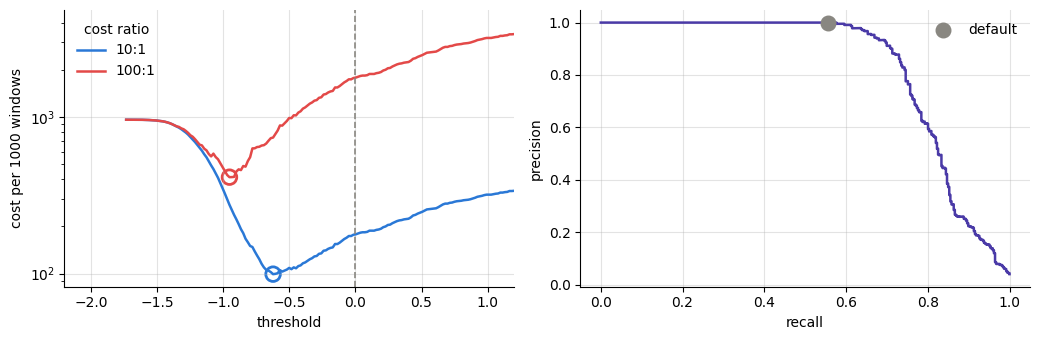

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.5))
for ratio, col in ((10, BLUE), (100, RED)):
    costs = np.array([expected_cost(t, ratio) for t in ts])
    ax[0].semilogy(ts, costs, color=col, lw=1.8, label=f"{ratio}:1")
    ax[0].scatter([ts[int(np.argmin(costs))]], [costs.min()], s=110,
                  facecolors="none", edgecolors=col, lw=2)
ax[0].axvline(0.0, color="#898781", ls="--", lw=1.2)
ax[0].set_xlabel("threshold"); ax[0].set_ylabel("cost per 1000 windows")
ax[0].set_xlim(-2.2, 1.2); ax[0].legend(frameon=False, title="cost ratio")

from sklearn.metrics import precision_recall_curve
pr, rc, _ = precision_recall_curve(is_bear, score)
ax[1].plot(rc, pr, color=VIOLET, lw=1.8)
ax[1].scatter([s0["recall"]], [s0["precision"]], s=110, color="#898781",
              zorder=5, label="default")
ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
ax[1].legend(frameon=False)
plt.tight_layout(); plt.show()

The model never changed. Only the number we compare its score against.

At **10:1** the cheapest threshold catches 82 % of spalls for a 2.9 % false-alarm rate —
an operating point a plant would actually accept. At **100:1** the arithmetic demands
96 % recall and accepts a **27 %** false-alarm rate, because at that ratio almost any
number of false alarms is cheaper than one missed gearbox.

That 27 % is worth stopping on. It is the correct answer to the question we asked, and
it is unusable as stated: nobody will action an alarm that fires on a quarter of all
windows. The resolution is that **the alarm is not per window, it is per machine**. A
real system requires several consecutive alarming windows before it raises anything,
which trades a little detection delay for an enormous reduction in nuisance alarms.
That aggregation is what Lab 10 asks you to build.

> The threshold is where engineering judgement enters a machine-learning system. It is
> the one number in the whole pipeline that a maintenance manager should choose and you
> should merely implement.

## 4. Class weights: moving along the curve, not off it

The other common response to imbalance is to tell the model that the rare class matters
more. `class_weight` multiplies the penalty for mistakes on a chosen class, so the fit
leans towards catching it.

In [9]:
from sklearn.metrics import precision_recall_fscore_support

rows = []
for w in (1, 2, 5, 10, 20, 50, 100):
    pw = cross_val_predict(svm(class_weight={"normal": 1, "imbalance": 1,
                                             "bearing": w}),
                           X, y, groups=groups, cv=cv, n_jobs=-1)
    p, r, f, _ = precision_recall_fscore_support(y, pw, labels=LAB,
                                                 zero_division=0)
    rows.append({"weight on bearing": w, "recall": r[2], "precision": p[2],
                 "F1": f[2], "overall accuracy": (pw == y).mean()})
weights = pd.DataFrame(rows).set_index("weight on bearing")
weights.round(3)

,recall,precision,F1,overall accuracy
weight on bearing,,,,
1,0.577,1.000,0.731,0.983
2,0.631,0.983,0.769,0.985
5,0.694,0.958,0.805,0.987
10,0.721,0.904,0.802,0.986
20,0.762,0.790,0.776,0.982
50,0.795,0.615,0.694,0.972
100,0.839,0.507,0.632,0.961


Recall climbs from 0.577 to 0.839; precision falls from 1.000 to 0.507. Overall
accuracy barely moves, which is the final piece of evidence against it as a score.

The important thing to understand is what did **not** happen. Class weights did not
give the model any new information about bearing spalls. They moved it along the same
precision–recall curve that section 3 drew by moving a threshold. If you plot the
weighted models on that curve they land on it, not above it.

So when should you use each?

| | use it when |
|---|---|
| **threshold** | you have a score and want to choose an operating point after training. Cheap, reversible, explicit. |
| **class weight** | the optimiser itself is being dominated by the majority class — usually when the rare class is so rare the fit ignores it entirely. |
| **resampling** | you need a specific library or loss that offers neither, or you are short of rare-class examples for the fit itself. |

For our problem the threshold is the right tool: it is one number, it can be changed
without retraining, and — critically for this course — it can be changed on the device
in Lecture 11 without re-exporting anything.

## 5. Cross-validation when the positive class is six runs

Lecture 8 established splitting by run. With a rare class there is a second problem
that grouping alone does not solve: **there may not be enough positive runs to put one
in every fold**, and when there is exactly one, that fold's recall is measured on a
single machine.

Compare the two schemes — not on their means, but on their spreads.

In [10]:
from sklearn.model_selection import KFold

def fold_recalls(splitter, use_groups):
    rec, n_runs = [], []
    for tr, te in (splitter.split(X, y, groups) if use_groups
                   else splitter.split(X)):
        m = svm().fit(X[tr], y[tr])
        p = m.predict(X[te])
        mask = y[te] == "bearing"
        rec.append((p[mask] == "bearing").mean() if mask.any() else np.nan)
        n_runs.append(len(np.unique(groups[te][mask])))
    return np.array(rec), n_runs

kf_rec, kf_runs = fold_recalls(KFold(5, shuffle=True, random_state=0), False)
gk_rec, gk_runs = fold_recalls(
    StratifiedGroupKFold(5, shuffle=True, random_state=0), True)

print(f"plain KFold over windows   mean {np.nanmean(kf_rec):.3f}  "
      f"sd {np.nanstd(kf_rec):.3f}   folds {np.round(kf_rec, 2)}")
print(f"StratifiedGroupKFold       mean {np.nanmean(gk_rec):.3f}  "
      f"sd {np.nanstd(gk_rec):.3f}   folds {np.round(gk_rec, 2)}")
print(f"\nbearing RUNS in each grouped test fold: {gk_runs}")

plain KFold over windows   mean 0.593  sd 0.062   folds [0.6  0.5  0.62 0.68 0.55]
StratifiedGroupKFold       mean 0.592  sd 0.342   folds [0.49 0.5  0.93 0.98 0.05]

bearing RUNS in each grouped test fold: [1, 2, 1, 1, 1]


The two means agree almost exactly, so the usual leakage story from Lecture 8 does not
appear here — a heavily regularised linear model has little capacity to memorise which
run it is looking at, and that is worth knowing in itself: **leakage hurts flexible
models most.**

The spreads tell a completely different story. Plain KFold reports a comfortable
sd of about 0.06. Grouped, the folds range from catching almost every spall to
catching almost none, with an sd around 0.34.

The grouped number is the honest one, and the honest conclusion is uncomfortable:
*with six spalls in the fleet, our recall estimate is worth roughly ±0.3.* Not
±0.06. The tight KFold spread was an artefact of testing on windows whose siblings
were in training.

> When the positive class is counted in single digits, quote the spread, not just the
> mean — and resist the urge to report the comfortable number.

## 6. Now take the labels away

Everything so far assumed a column telling you which runs were faulty. Where did it
come from?

Someone had to run a machine with a known spall in it, or find the maintenance record
afterwards and match it to the right week of data. In a real plant, after a year of
monitoring, you have:

* thousands of hours of healthy running, **unlabelled** — the machine simply did not break;
* a handful of known failures, often noticed after the data was overwritten;
* a large middle ground nobody wrote anything down about.

Supervised learning needs labelled examples of every fault you want to catch. That is
the one thing nobody has.

**Anomaly detection asks a different question.** Instead of *"which of these three
faults is this?"* it asks *"is this machine behaving as it always has?"* — and that
question can be answered from healthy data alone.

The consequences are worth stating plainly:

| | supervised | anomaly detection |
|---|---|---|
| needs | labelled faults | healthy data only |
| catches | the faults you trained on | anything unusual |
| tells you | which fault it is | only that something changed |
| fails when | a new fault type appears | the healthy baseline shifts (section 9) |

The last row of each column is the real trade. A supervised model is blind to a failure
mode it has never seen; an anomaly detector notices it but cannot name it.

## 7. Three detectors, none of which sees a fault label

All three are fitted on **healthy training windows only**. The fault windows exist in
this notebook solely so that we can measure how well the detectors did — a real
deployment would not have them.

1. **mean ± kσ** — standardise using healthy statistics, score each window by its
   largest absolute z-score. This is what an engineer builds by hand, and it is the
   baseline the other two have to beat.
2. **Isolation forest** — random splits isolate unusual points in fewer cuts. Fast,
   assumes nothing about the shape of the healthy region.
3. **PCA reconstruction error** — project onto the principal directions of the healthy
   data, project back, and measure what did not survive. A linear autoencoder: the same
   idea as the neural version, but explainable and small.

In [11]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score

faulty = (y != "normal").astype(int)
DET = ["mean ± kσ", "isolation forest", "PCA residual"]
S = {k: np.zeros(len(y)) for k in DET}
ncomp = []

for tr, te in cv.split(X, y, groups):
    healthy = tr[y[tr] == "normal"]              # <-- the only data used to fit
    sc = StandardScaler().fit(X[healthy])
    A = sc.transform(X)

    S["mean ± kσ"][te] = np.abs(A[te]).max(1)

    iso = IsolationForest(n_estimators=200, random_state=0,
                          n_jobs=-1).fit(A[healthy])
    S["isolation forest"][te] = -iso.score_samples(A[te])

    var = np.cumsum(PCA().fit(A[healthy]).explained_variance_ratio_)
    k = int(np.searchsorted(var, 0.95) + 1)       # keep 95 % of healthy variance
    ncomp.append(k)
    pc = PCA(n_components=k, random_state=0).fit(A[healthy])
    resid = A[te] - pc.inverse_transform(pc.transform(A[te]))
    S["PCA residual"][te] = np.sqrt((resid ** 2).sum(1))

print(f"PCA kept {int(np.mean(ncomp))} of {X.shape[1]} components\n")
rows = []
for k, v in S.items():
    thr = np.quantile(v[y == "normal"], 0.99)
    rows.append({"detector": k,
                 "ROC-AUC": roc_auc_score(faulty, v),
                 "false alarms": (v[y == "normal"] > thr).mean(),
                 "recall, any fault": (v[y != "normal"] > thr).mean(),
                 "recall, bearing": (v[y == "bearing"] > thr).mean(),
                 "recall, imbalance": (v[y == "imbalance"] > thr).mean()})
pd.DataFrame(rows).set_index("detector").round(3)

PCA kept 7 of 12 components



,ROC-AUC,false alarms,"recall, any fault","recall, bearing","recall, imbalance"
detector,,,,,
mean ± kσ,0.959,0.01,0.833,0.514,0.993
isolation forest,0.963,0.01,0.828,0.577,0.954
PCA residual,0.943,0.01,0.584,0.637,0.557


Read the bearing column first, then compare it with section 2.

The supervised model, which was given every fault label in the fleet, reached a bearing
recall of **0.577**. The isolation forest, which was never shown a single fault,
reaches **0.577** as well. The PCA residual reaches **0.637**.

That is the headline of the second half of this lecture: **on this problem, labelling
your faults bought you almost nothing.** Be careful how far you push it — the
supervised model achieves its recall at zero false alarms, while the detectors are
paying 1 %, and the supervised model can also name the fault. But the idea that you
cannot start without labelled failures is simply wrong, and it is the reason most
industrial monitoring systems are anomaly detectors.

Now the imbalance column, which is the interesting failure. The PCA residual catches
only 56 % of imbalance windows against the isolation forest's 95 %. The reason is
structural: imbalance mostly *scales up* a direction the healthy data already varies
along, so PCA reconstructs it almost perfectly and the residual stays small.

> **Reconstruction error is blind to faults that live inside the healthy subspace.**
> It is excellent at detecting *new* behaviour and poor at detecting *more of the same*.

That is not a bug to tune away. It is a property to know, and a reason to run more than
one detector.

## 8. Setting the threshold without any faults

A detector produces a score. An alarm needs a number to compare it against, and in the
no-labels world you cannot choose that number by maximising anything on faults — you
have none.

What you can do is state a **tolerable false-alarm rate** and read the threshold off
the healthy score distribution. If you set the threshold at the 99th percentile of
healthy training scores, then by construction about 1 % of healthy windows will alarm.

That turns the threshold into a question the plant can answer: *how many nuisance
alarms per week will maintenance tolerate before they stop answering the phone?*

In [12]:
QS = [0.80, 0.90, 0.95, 0.98, 0.99, 0.995, 0.999]
wpr = len(y) // len(fleet)                    # windows in one acquisition
rows = []
v = S["isolation forest"]
for q in QS:
    thr = np.quantile(v[y == "normal"], q)
    rows.append({"quantile": q,
                 "false alarms [%]": (v[y == "normal"] > thr).mean() * 100,
                 "per acquisition": (v[y == "normal"] > thr).mean() * wpr,
                 "bearing caught [%]": (v[y == "bearing"] > thr).mean() * 100})
pd.DataFrame(rows).set_index("quantile").round(2)

,false alarms [%],per acquisition,bearing caught [%]
quantile,,,
0.800,20.01,12.20,81.42
0.900,10.01,6.11,71.31
0.950,5.00,3.05,69.40
0.980,2.01,1.23,62.30
0.990,1.01,0.61,57.65
0.995,0.51,0.31,55.74
0.999,0.11,0.07,47.54


Read the middle column as the one a plant manager understands: at the 99th percentile
you get about 0.6 false alarms in every acquisition of 61 windows; at the 80th
percentile you get twelve, and nobody will look at any of them.

Two practical notes.

**Fit the quantile on data the detector did not train on.** The healthy scores in the
training set are optimistically low, exactly as training accuracy is optimistically
high. Hold out healthy runs, or use the out-of-fold scores as we did here.

**Nothing forces you to alarm on single windows.** Requiring *m* of the last *n*
windows to exceed the threshold cuts nuisance alarms sharply while delaying detection
by at most *n* windows — 128 ms each, so a handful of seconds. Lab 10 asks you to
choose *m* and *n* and defend them.

## 9. A threshold has a shelf life

Everything so far assumed the healthy baseline stays where you found it. It does not.

Mounts relax. Ambient temperature swings with the season. A bearing is replaced with a
different brand. A neighbouring machine is installed. None of this is a fault, and all
of it moves the features.

The drift campaign is one healthy machine measured monthly for four years, with a real
spall appearing in the last six months. Nothing else breaks.

In [13]:
drift = make_drift_campaign(seed=31)
Xd, yd, gd = build_table(drift)
wpr_d = len(yd) // len(drift)
month = np.repeat([r["month"] for r in drift], wpr_d)
FAULT_FROM = min(r["month"] for r in drift if r["label"] != "normal")
BURN = 12

# the threshold an engineer sets in the first year, and never revisits
base = month < BURN
sc0 = StandardScaler().fit(Xd[base])
z_fixed = np.abs(sc0.transform(Xd)).max(1)
thr0 = np.quantile(z_fixed[base], 0.99)
alarm_fixed = z_fixed > thr0

print("month band   alarm rate (threshold fixed in year 1)")
for lo in range(0, len(drift), 6):
    m = (month >= lo) & (month < lo + 6)
    tag = "   <- real spall" if lo >= FAULT_FROM else ""
    print(f"   {lo:2d}–{lo+5:2d}      {alarm_fixed[m].mean():.3f}{tag}")

month band   alarm rate (threshold fixed in year 1)
    0– 5      0.011
    6–11      0.011
   12–17      0.016
   18–23      0.202
   24–29      0.126
   30–35      0.238
   36–41      0.478
   42–47      1.000   <- real spall


By months 36–41 the detector is firing on nearly half the windows of a **perfectly
healthy machine**. Long before that, maintenance stopped answering. When the real spall
arrives at month 42 the alarm is already permanently on, and nobody is listening.

This is the failure mode that kills monitoring projects in the field, and it is not a
modelling error — the detector was right on day one and the machine changed underneath
it.

The fix is to re-estimate the baseline from recent data. The subtlety is *which* recent
data: if you blindly include everything, a slowly growing fault gets absorbed into the
baseline and becomes the new normal. A workable rule is to re-estimate from a trailing
window of months that did **not** alarm.

In [14]:
WIN_M, ALARM_HI = 12, 0.20
alarm_roll = np.zeros(len(month), bool)
accepted = set(range(BURN))            # months the operator accepts as healthy

for m0 in range(BURN, len(drift)):
    past = np.isin(month, sorted(m for m in accepted if m >= m0 - WIN_M))
    cur = month == m0
    sc = StandardScaler().fit(Xd[past])
    z_past = np.abs(sc.transform(Xd[past])).max(1)
    z_cur = np.abs(sc.transform(Xd[cur])).max(1)
    alarm_roll[cur] = z_cur > np.quantile(z_past, 0.99)
    if alarm_roll[cur].mean() < ALARM_HI:      # a quiet month joins the baseline
        accepted.add(m0)

h = (month >= BURN) & (month < FAULT_FROM)
f = month >= FAULT_FROM
print(f"{'':22s} {'healthy months':>15s} {'the real spall':>16s}")
print(f"{'threshold fixed':22s} {alarm_fixed[h].mean():15.3f} "
      f"{alarm_fixed[f].mean():16.3f}")
print(f"{'baseline re-estimated':22s} {alarm_roll[h].mean():15.3f} "
      f"{alarm_roll[f].mean():16.3f}")

                        healthy months   the real spall
threshold fixed                  0.212            1.000
baseline re-estimated            0.066            1.000


Re-estimating cuts false alarms on the healthy years from 21 % to 7 %, and still
catches every window of the real spall.

Note the `ALARM_HI` guard: months that alarmed are **not** admitted to the baseline. Take
it out and the detector will calmly learn that a failing bearing is the new normal —
the classic way an adaptive threshold hides a slow degradation. This is the same trade
as before in a different costume: adapt too slowly and you drown in false alarms;
adapt too fast and you adapt to the fault.

> Write down when the baseline was last re-estimated, and on what data. In two years
> somebody will need to know.

## 10. End to end: the alarm specification

An alarm is not a model. It is a small document that says what is measured, what it is
compared against, how often it is allowed to be wrong, and when it expires.

We build it from the **mean ± kσ** detector rather than the isolation forest. The
isolation forest is more accurate, but a deployed alarm has to run on an ESP32, and the
whole of this detector is 12 means, 12 standard deviations and one threshold — twenty-five
numbers and a loop. The isolation forest's 200 trees stay in the cloud, which is exactly
the hybrid architecture this course committed to in Lecture 8.

In [15]:
# The alarm is built from the max|z| detector, scored out of fold so that no
# window is judged by a baseline fitted on its own run.
base = S["mean ± kσ"]
Q = 0.99
thr = float(np.quantile(base[y == "normal"], Q))

print(f"threshold at the {Q:.0%} healthy quantile: {thr:.3f}")
print(f"false alarms on healthy windows: {(base[y=='normal'] > thr).mean():.4f}")
print(f"bearing recall:                  {(base[y=='bearing'] > thr).mean():.3f}")
print("\n(section 5 measured the fold-to-fold spread of a recall like this at "
      "about 0.3 —\n the specification must carry that, not just the mean)")

threshold at the 99% healthy quantile: 4.038
false alarms on healthy windows: 0.0101
bearing recall:                  0.514

(section 5 measured the fold-to-fold spread of a recall like this at about 0.3 —
 the specification must carry that, not just the mean)


Now the single cheapest improvement in this entire lecture, and it is not a model.

A bearing spall does not produce one anomalous window and then stop. It produces a run
of them. A healthy machine on a noisy afternoon produces isolated ones. So require the
alarm to **persist**: fire only when *m* of the last *n* windows exceed the threshold.

In [16]:
def persist(flags, run_ids, m, n):
    # Alarm when m of the last n windows of the SAME run exceed the threshold.
    out = np.zeros(len(flags), bool)
    for r in np.unique(run_ids):
        idx = np.where(run_ids == r)[0]
        f = flags[idx]
        for i in range(n - 1, len(f)):
            out[idx[i]] = f[i - n + 1:i + 1].sum() >= m
    return out

raw = base > thr
healthy_runs = [r for r in np.unique(groups) if y[groups == r][0] == "normal"]
rows = []
for m, n in ((1, 1), (2, 3), (3, 5), (4, 7)):
    p = persist(raw, groups, m, n)
    rows.append({"rule": f"{m}-of-{n}",
                 "false alarms / window": p[y == "normal"].mean(),
                 "bearing recall": p[y == "bearing"].mean(),
                 "healthy machines that alarmed": np.mean(
                     [p[groups == r].any() for r in healthy_runs]),
                 "added delay [ms]": (n - 1) * HOP / FS * 1000})
pd.DataFrame(rows).set_index("rule").round(4)

,false alarms / window,bearing recall,healthy machines that alarmed,added delay [ms]
rule,,,,
1-of-1,0.0101,0.5137,0.2500,0.0
2-of-3,0.0029,0.5000,0.0682,128.0
3-of-5,0.0004,0.4918,0.0152,256.0
4-of-7,0.0000,0.4754,0.0000,384.0


Read the last two columns together.

With no persistence, **a quarter of perfectly healthy machines raise at least one
alarm** somewhere in their four-second acquisition. With a 3-of-5 rule that falls to
1.5 %, for a cost of 0.022 in bearing recall and 256 ms of delay.

That is a twenty-five-fold reduction in nuisance alarms, bought with a quarter of a
second and two lines of code. No change of model, no extra data, no labels. It is worth
more than every hyperparameter in Lecture 9 put together, and it is the kind of thing
that gets skipped because it does not look like machine learning.

> Before reaching for a better model, ask whether the decision rule on top of the
> current one is doing its job.

In [17]:
M, N = 3, 5
final = persist(raw, groups, M, N)

# the scaler the device will carry: fitted on every healthy window we have
scaler = StandardScaler().fit(X[y == "normal"])

spec = {
    "lecture": 10,
    "detector": "max_abs_zscore",
    "feature_names": list(FEATURE_NAMES),
    "scaler_mean": [float(v) for v in scaler.mean_],
    "scaler_scale": [float(v) for v in scaler.scale_],
    "threshold": thr,
    "threshold_quantile": Q,
    "persistence": {"m": M, "n": N},
    "expected_false_alarm_rate_per_window": float(final[y == "normal"].mean()),
    "expected_bearing_recall": float(final[y == "bearing"].mean()),
    "recall_uncertainty_note": "measured on 6 spalls; fold-to-fold sd about 0.3",
    "fitted_on_healthy_windows": int((y == "normal").sum()),
    "window": int(WIN), "hop": int(HOP), "fs": int(FS),
    "review_after_months": 12,
}
with open("lecture10_alarm.json", "w") as fh:
    json.dump(spec, fh, indent=1)

print(f"saved lecture10_alarm.json — {2*len(scaler.mean_) + 1} numbers, "
      f"a {M}-of-{N} rule, and an expiry date")
print("this file is the input to Lecture 11 -- keep it")

saved lecture10_alarm.json — 25 numbers, a 3-of-5 rule, and an expiry date
this file is the input to Lecture 11 -- keep it


Twenty-five numbers, a persistence rule and an expiry date. Compare that with Lecture
9's classifier: 63 numbers and no expiry date, because a model trained on labelled
faults does not drift in quite the same way — but it also cannot notice a fault nobody
labelled.

`review_after_months` is not decoration. Section 9 showed that a threshold set once is
wrong within two years, and an alarm specification that does not say when it expires is
incomplete.

## What to remember

1. **Compute the majority-class accuracy first.** On this fleet it is 0.880 — the same
   number Lecture 9 was pleased with.
2. **Report the confusion matrix.** Accuracy 0.983 and bearing recall 0.577 are the same
   model.
3. **Recall answers "did we catch it"; precision answers "was the alarm real".** Name
   which one your application cares about before you optimise anything.
4. **The threshold is an engineering decision, not a hyperparameter.** Get the cost
   ratio from the people who pay the costs.
5. **Class weights move you along the precision–recall curve.** They do not create
   information.
6. **With a rare class, report the spread across folds.** Six spalls buys you a recall
   estimate worth about ±0.3.
7. **Anomaly detection needs only healthy data** — and here it matched the supervised
   model's bearing recall without ever seeing a fault.
8. **Reconstruction error is blind to faults inside the healthy subspace.** Run more
   than one detector.
9. **Set the threshold from a healthy quantile**, and state the false-alarm rate you
   are buying.
10. **Baselines age.** Re-estimate them, exclude the months that alarmed, and write down
    when you last did it.

## Exercises

1. **The per-machine decision.** Section 3 found that a 100:1 cost ratio demands a 27 %
   per-window false-alarm rate. Aggregate to a per-run decision — a run alarms if more
   than a fraction *p* of its windows do — and redo the cost sweep over *p* and the
   threshold jointly. What is the cheapest pair, and is it operationally sane?

2. **F1 versus cost.** Find the threshold that maximises F1 on the bearing class.
   Compare it with the cost-optimal thresholds at 10:1 and 100:1. What cost ratio is
   F1 implicitly assuming?

3. **How rare is too rare?** Rebuild the fleet with `counts={"normal": 132,
   "imbalance": 12, "bearing": n}` for *n* in 3, 6, 12, 24. Plot bearing recall and its
   fold-to-fold spread against *n*. At what point does the estimate become worth
   quoting?

4. **A fault the model has never seen.** Add a fourth state to `rig.py` — a loose
   mounting bolt, say, which raises the frame resonance amplitude sharply. Train the
   supervised model on the original three classes only, and test both it and the
   isolation forest on the new fault. Which one notices? This is the argument for
   anomaly detection in one experiment.

5. **Beat the baseline.** The `mean ± kσ` detector scores each window by its single
   largest z-score, which throws away the other eleven. Replace it with the Mahalanobis
   distance using the healthy covariance. Does it beat the isolation forest? Is it still
   small enough to deploy?

6. **Persistence.** Sweep *m* and *n* in the persistence rule of section 10 over
   sensible ranges. Plot false alarms per acquisition against detection delay in
   milliseconds. Which pair would you defend to a maintenance manager?

7. **Drift, faster.** Double the drift rates in `make_drift_campaign` and re-run
   section 9. How long does the fixed threshold survive? Does the re-estimated one still
   catch the spall, or has the baseline moved too fast to trust?

8. **Towards Lecture 11.** Write a pure-Python function — no NumPy — that reads
   `lecture10_alarm.json`, takes one window's twelve features, and returns True if the
   window alarms. Add the persistence rule using a fixed-length list as a ring buffer.
   Count its multiplications and compare with the Lecture 9 classifier.

## References

**Evaluation and imbalance**

* Saito, T. and Rehmsmeier, M. (2015). *The precision–recall plot is more informative
  than the ROC plot when evaluating binary classifiers on imbalanced datasets.*
  PLOS ONE, 10(3), e0118432.
* Provost, F. and Fawcett, T. (2001). *Robust classification for imprecise
  environments.* Machine Learning, 42, 203–231. The cost-curve argument of section 3.
* He, H. and Garcia, E. A. (2009). *Learning from imbalanced data.* IEEE Transactions
  on Knowledge and Data Engineering, 21(9), 1263–1284.
* Elkan, C. (2001). *The foundations of cost-sensitive learning.* IJCAI, 973–978.

**Anomaly detection and drift**

* Liu, F. T., Ting, K. M. and Zhou, Z.-H. (2008). *Isolation forest.* ICDM, 413–422.
* Chandola, V., Banerjee, A. and Kumar, V. (2009). *Anomaly detection: a survey.*
  ACM Computing Surveys, 41(3).
* Qin, S. J. (2012). *Survey on data-driven industrial process monitoring and
  diagnosis.* Annual Reviews in Control, 36(2), 220–234. PCA residual monitoring —
  the *Q* statistic — as used in section 7.
* Gama, J. et al. (2014). *A survey on concept drift adaptation.* ACM Computing
  Surveys, 46(4).

**Tools**

* scikit-learn user guide, *Metrics and scoring*:
  https://scikit-learn.org/stable/modules/model_evaluation.html
* scikit-learn user guide, *Novelty and outlier detection*:
  https://scikit-learn.org/stable/modules/outlier_detection.html

Generated by Claude and customized by

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>